# Integral Approximation

Goals:

* Use arrays to streamline calculations.
* Use `for` loops to automate repetitive tasks.
* Define more complex functions.
* Interpret documentation to understand a rarely used method, specifically  `matplotlib.patches.rectangle()`.

This activity is broken into three topics, for the three new tools you'll need.  These tools are not automatically loaded by python, instead they are defined in packages.  Run the code block below to load these packages.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Arrays

An array is a list of objects defined by the numpy package.  How is a numpy array different from a python list?
* Elements in an array all need to be of the same type.  A list can contain a string, a function and a number.  An array must be all numbers, or all functions, or all strings.
* There are lots of mathematical operations built into the array class of objects.  They allow us to perform operations on the entire array instead of on single elements.

If we have a list of numbers that we'd like to turn into an array, we can use the `np.array()` method.  The list is the argument.

In [2]:
x=np.array([2,3,5,6,7,10,15])
print(x)

[ 2  3  5  6  7 10 15]


When we apply an arithmetic operation or a function (that takes a number as an input) to an array, it applies that operation to each element of the array.

In [3]:
y=x+3
print(y)

[ 5  6  8  9 10 13 18]


Array operations are used for graphing functions.  Instead of plugging in the x values we want to plot by hand, we can use the `np.arange()` method to produce an array containing an arithmetic sequence.  It takes three arguments (the last one is optional and defaults to 1).
* The first argument is the first element of the array.
* The third argument is how much we add to each element to get the next element.
* The sequence ends when it reaches the second argument.  The second argument itself is not included in the sequence.

Here's an example.

In [8]:
x=np.arange(-2,3,0.1)
print(x)

[-2.00000000e+00 -1.90000000e+00 -1.80000000e+00 -1.70000000e+00
 -1.60000000e+00 -1.50000000e+00 -1.40000000e+00 -1.30000000e+00
 -1.20000000e+00 -1.10000000e+00 -1.00000000e+00 -9.00000000e-01
 -8.00000000e-01 -7.00000000e-01 -6.00000000e-01 -5.00000000e-01
 -4.00000000e-01 -3.00000000e-01 -2.00000000e-01 -1.00000000e-01
  1.77635684e-15  1.00000000e-01  2.00000000e-01  3.00000000e-01
  4.00000000e-01  5.00000000e-01  6.00000000e-01  7.00000000e-01
  8.00000000e-01  9.00000000e-01  1.00000000e+00  1.10000000e+00
  1.20000000e+00  1.30000000e+00  1.40000000e+00  1.50000000e+00
  1.60000000e+00  1.70000000e+00  1.80000000e+00  1.90000000e+00
  2.00000000e+00  2.10000000e+00  2.20000000e+00  2.30000000e+00
  2.40000000e+00  2.50000000e+00  2.60000000e+00  2.70000000e+00
  2.80000000e+00  2.90000000e+00]


One great application for arrays is to produce the x and y coordinates for a graph.

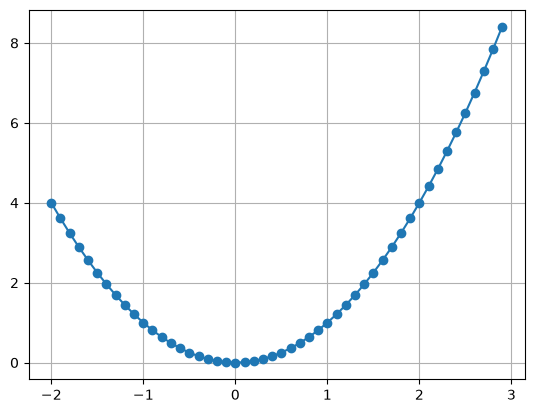

In [12]:
def f(x):
  return x**2

y=f(x)

plt.plot(x,y,'o-')
plt.grid()
plt.show()

### Exercise 1

* What function did we graph here? f(x) = x^2
* You should notice the graph looks like a sequence of line segments, not a parabola.  To see why, add a third argument `'o'` to `plt.plot()`. This is an optional format argument built into the `plot()` method.  Don't forget the comma or the quotation marks (it is a string). Rerun the code. What does this do? this add dots to the graph were the points lie
* Now you should see that to make a smooth graph, we need more points.  We can obtain that by defining `x` to have a much smaller step size.  Try it.

Now we'll demonstrate some other array functions that might come in handy.

In [13]:
np.sum(x) #sums the elements of x

np.float64(22.50000000000011)

In [14]:
np.prod(x) #multiplies the elements of x


np.float64(3.82114615689316e-15)

In [15]:
x[2:6] #geting slices (and single elements) works on arrays just like lists

array([-1.8, -1.7, -1.6, -1.5])

## Integral Approximation

Another great application of arrays is to approxmiate the value of an integral.  Recall that
$$\int_a^b f(x)~dx\approx\sum_{i=1}^n f(x_i^*)\Delta x$$

If we write an array of test points $x_i^*$, we can evaluate $f$ on the entire array at once.

### Exercise 2
Write a code cell that computes the $L_{10}$ approximation of $$\int_1^6 x^2~dx.$$
Your cell should
* Defines a variable `n=10`.
* Define a variable `deltax` in terms of `n`.
* Use `np.arange()` to save an array of `n` left endpoints to the variable `x`.  (Hint: What is the step size?)   This would be a good time to stop and check that you're on the right track.  If you print `x` you should see the output `[1. 1.5 2. 2.5 3. 3.5 4. 4.5 5. 5.5]`
* Apply `f` to `x`, multiply by `deltax` and assign the result to the variable `left`.
* Print the sum of `left`.  This is your approximation.  You should get `63.125`

In [26]:
n = 20
deltax = (6-1)/n

x = np.arange(1,6,deltax)
print(x)
print(deltax)

def int_approx(x):
    return x**2 * deltax

left = int_approx(x)

print(left.sum())


[1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25 3.5  3.75 4.   4.25
 4.5  4.75 5.   5.25 5.5  5.75]
0.25
67.34375


If you've written your code well, the number 10 should only appear when it was assigned to `n`.  All other places where 10 was relevant should be `n`s.  This way you can change the value of `n` and get a different approximation. Try `n=20`.  The output should be `67.34375`.

## Flow-Control: For Loops

What is python doing when you apply a function like `**2` to an array?  Imagine for a moment that you are going to manually perform such an operation.  You could write code that squares the first element, then the second, then the third...

In [27]:
y[0]=x[0]**2
y[1]=x[1]**2
y[2]=x[2]**2
y[3]=x[3]**2

This would be tedious, and when would you stop?  You would need to write a different procedure for each different length of array.

Fortunately, these operations are already written for arrays, but there are times that we want to define an operation to happen many times, perhaps a variable number, and we can't use an array for it.  This is what the `for` loop is for.  The `for` loop is an example of *flow-control*, it isn't an instruction on its own.  Instead it tells the python interpreter which instructions to run.  

For our first example, let's work with strings.  Here is a function.   Try applying it to your name and see what it outputs (maybe you can guess ahead of time).

In [29]:
def firstLetter(name):
  return name[0]+' is for '+name

print(firstLetter('Shane'))

S is for Shane


If we wanted to perform this function on a bunch of names, we can write a `for` loop.

In [30]:
students=['Casey', 'Eric', 'Yuanzhe', 'Ogedi', 'Santiago', 'Angela', 'Hans']


for name in students:
  print(firstLetter(name))

C is for Casey
E is for Eric
Y is for Yuanzhe
O is for Ogedi
S is for Santiago
A is for Angela
H is for Hans


The syntax is

`for {variable} in {list}:`

> `instructions(indented)`

Important notes
* The variable is entirely internal to the `for` loop.  It does not have any meaning outside.  If you use the same name as an already existing variable, the existing variable will be ignored by the `for` loop, and will be unaltered when the loop completes.
* The `for` loop repeats over and over, each time assigning the next element of the list to the variable, until all have been used.
* For each value of the variable, python performs the indented instructions until it comes to an unindented line (or the end of the cell).
* Unlike a `def`, the `for` loop is not defining a function.  It does not return anything.

We can use a `for` loop to replicate some of the functionality of an array.  This is a good exercise for learning.  In practice we should just use arrays when they are available.

In [31]:
x=[2,3,5,7,10]
for i in x:
  print(i**2)

4
9
25
49
100


What if we wanted to sum these numbers?  A useful trick is to use a total variable and add to it each time the loop runs.  

In [32]:
total=0       #set total to begin at 0

for i in x:
  total=total+i**2  # add i**2 to total and save the value back to total

print(total)  #after the for loop is complete, print the value of total

187


This is a very important technique to understand.  Make sure every step makes sense to you.

### Exercise 3
* Write a code cell that computes the product of the numbers in `x` using a `for` loop.  What should your total start with?  What should each step of the loop do?  The answer should be 2100.

In [36]:
product = 1

for i in x:
    product = product * i

print(product)  #after the for loop is complete, print the value of product

2100


Instead of a list we can use an *iterator* to define the values of the variable in a for loop.
* An iterator contains code that will generate a list of values.
* It does not contain the actual values.  It generates the next one as needed.
* For you, the distinction between lists and iterators isn't generally meaningful. Just don't try to call for an element or a slice of an iterator.

The most common iterator is the `range()` iterator.  It takes one argument.  I bet you can guess what it does after you run this code cell.

In [37]:
for i in range(10):
  print(i)

0
1
2
3
4
5
6
7
8
9


The range iterator can be useful when we want to reference other elements of the list.  Instead of iterating over the elements, we iterate over an index variable.  To know how high the index variable should count, we can use the `len()` function.  The following two expressions produce the same output.

In [38]:
for i in range(len(students)):
  print(students[i])

for name in students:
  print(name)

Casey
Eric
Yuanzhe
Ogedi
Santiago
Angela
Hans
Casey
Eric
Yuanzhe
Ogedi
Santiago
Angela
Hans


Here is an example where the index variable is more useful.  Think about what trouble you'd run into if your for loop was

`for name in students:`



In [41]:
for i in range(len(students)-1):
  print(students[i]+' comes before '+students[i+1])

Casey comes before Eric
Eric comes before Yuanzhe
Yuanzhe comes before Ogedi
Ogedi comes before Santiago
Santiago comes before Angela
Angela comes before Hans


### Exercise 4

* What are the `students[i]` and `students[i+1]` in the printed string? students[i] represents the first student and the studnets[1+1] represents the next index or the next student
* Why did we use the length of students minus 1 as the upper bound of our iterator?  What would happen without the `-1`?
because the next line uses '[1+1]', if we didn't use '-1' then we'd run out of indexs and get a error, also we print one less statements than there are students as each statement uses two students, so 7 students but only 6 lines
* Rewrite this code to print a list of who comes after whom. There are easy ways and hard ways to do this.

In [43]:
for i in range(len(students)-1):
    print(students[i+1]+' comes after '+students[i])

Eric comes after Casey
Yuanzhe comes after Eric
Ogedi comes after Yuanzhe
Santiago comes after Ogedi
Angela comes after Santiago
Hans comes after Angela


One use of `for` loops is to build a list. This is similar to our techniqure for computing a sum.  Instead of adding values to a total variable, we append them to a list.  Here is a list of the first 10 square numbers.

In [44]:
squares=[] #an empty list

for i in range(10):
  squares.append(i**2)

print(squares)


[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


Of course, we could have done this more easily with an array.  

### Exercise 5
* Write a code cell that uses a `for` loop to create a list consisting of the letters of your name. Then print your list.  Note that a string is not a list, but the `len()` function does work.  You should also remember how to get a certain letter from a string.

In [45]:
def name_as_list(name):
    letters=[]
    for i in range(len(name)):
        letters.append(name[i])
    return letters

print(name_as_list('Shane'))

['S', 'h', 'a', 'n', 'e']


One final clever idea is to use a for loop to perform an operation n times. Newton's method comes to mind.

In [47]:
def new(a):
  x=a-(a**2-2)/(2*a)  # newtons method for f(x)=x^2-2
  print(x)            # print the new value
  return x            # returns the new value

a=5 # initial guess

for i in range(10):
  a=new(a)

2.7
1.7203703703703703
1.44145536817765
1.414470981367771
1.4142135857968836
1.4142135623730951
1.414213562373095
1.4142135623730951
1.414213562373095
1.4142135623730951


Notice that we didn't use the variable of the `for` loop at all.  Making it run through an iterator of 10 elements just ensured that the instructions were performed 10 times.

Flow control is where programming becomes powerful.  A few lines of code can set off millions of operations.  It is also where coding becomes hard.  The first step is to understand what the `for` loop is instructing python to do in examples like these. The next step is understanding how to design a `for` loop to solve the problems that you want to solve.

## Case-study: the `rectangle()` method

Arrays, for loops, functions, lists and strings are all things that you should memorize if you intend to use python regularly.  Much of the time, though, you'll need a function once for a specific application, and never again (or infrequently).  Let's model how to do this.

I want to add some rectangles to my plots so I can visualize the left-hand approximation.  Let's search for "matplotlib python rectangles" in our favorite search engine. We might find some nice question and answers on popular forums.  These are interesting, but somewhere in the list should be the official matplotlib documentation for its rectangle function.  Here's the link I found.

[https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html)



The first line on the page gives us the syntax of the command

`class matplotlib.patches.Rectangle(xy, width, height, angle=0.0, **kwargs)`

* `class` means that this is a class of objects. This class of objects likely has its own methods (you'll find them lower on the page).
* `matplotlib.patches.Rectangle` is the method that creates an object of this class.  Notice this is in the `patches` library of `matplotlib`.  We've only imported `matplotlib.pyplot` so we'll need to load this library too.
* The rest of the line tells us about the arguments:  
 * `xy` `width` and `height` are the three mandatory arguments.
 * `angle=0.0` is an example of a keyword argument. We include it by writing `angle=value`.  If we don't include it, this line tells us that it defaults to `0.0`.
 * `**kwargs` means that there are potentially other keyword arguments that we can add.

Below this line the parameters (arguments) are described in detail.  For example `(x,y)` has the form `(float,float)`.  A "float" is a floating-point number.  For our purposes, it is a number with a decimal point (in contrast to an integer).  That means that the argument `xy` needs to be an ordered pair of numbers. That matches the description: "The bottom and left rectangle coordinates."


Let's implement this command.  First we'll need to import `matplotlib.patches`

In [48]:
import matplotlib.patches as patches

Let's define a rectangle.  We'll need to choose a lower left corner `xy`, a `width` and a `height`.

In [49]:
rect=patches.Rectangle((2,3), 6, 4)
print(rect)

Rectangle(xy=(2, 3), width=6, height=4, angle=0)


That was exciting....

Now how do we actually add our rectangle to a picture?  The class doesn't tell us that.  We'd need to find the documentation for a plot and see what method adds pacthes like ours.  I'll save you the digging around.  Patches can be added to objects called `axes`. The following code creates an axis, adds a graph, and adds our rectangle.

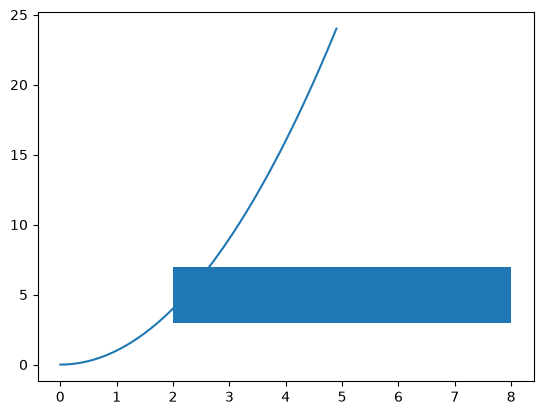

In [50]:
x=np.arange(0,5,0.1)
ax=plt.axes()          # defines an axis in the drawing
ax.plot(x,x**2)
rect=patches.Rectangle((2,3), 6, 4)
ax.add_patch(rect)
plt.show()

The code creates an object `ax` which is an axis in the current picture.`pyplot` always has a current picture ready to add to, until you call `plt.show()`.  We can call the `.plot()` method and the `.add_patches()` to add to our axis.

We can try adding a keyword argument.  The documentation lists `fill` as a keyword that is a `bool`.  
* `bool` means a boolean.  It is `True` or `False`.
* Booleans are not strings.  No ' required.
* Be sure to capitalize `True` or `False`.

Here is an example with the keyword argument added.


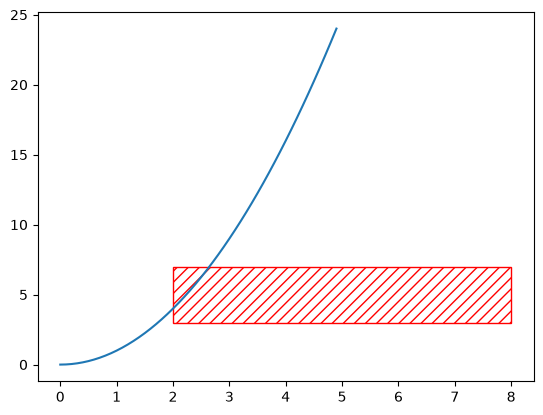

In [54]:
x=np.arange(0,5,0.1)
ax=plt.axes()
ax.plot(x,x**2)
rect=patches.Rectangle((2,3), 6, 4, fill=False, color='red', hatch='///')
ax.add_patch(rect)
plt.show()

### Exercise 6

* Add the keyword argument `color='red'` to the rectangle we assigned to `rect`.
* Look up the keyword `hatch` in the documentation.  It suggests several possible strings that `hatch` can be set equal to.  Give one a try.

There are lots of uses of rectangles.  We would like to draw a picture of the approximation of an integral.

## Exercise 7
Use a `for` loop and `patches.Rectangle()` to display the rectangles of the $L_{10}$ approximation of $$\int_1^6 x^2~dx$$
* Assign the value `10` to the variable `n`
* Define a variable `deltax` in terms of `n`.
* Use `np.arrange()` to save an array of `n` left endpoints to the variable `xvalues`.
* Create an axis
* Write a `for` loop that takes each `x` in `xvalues` and
  * Defines a rectangle at `(x,0)` with width `deltax` and height equal to `f(x)`
  * Adds that rectangle to the axis
* Define an array `x` with a smaller step size and use it to add a plot of $y=x^2$ to the axis
* Show the plot.


[1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5]


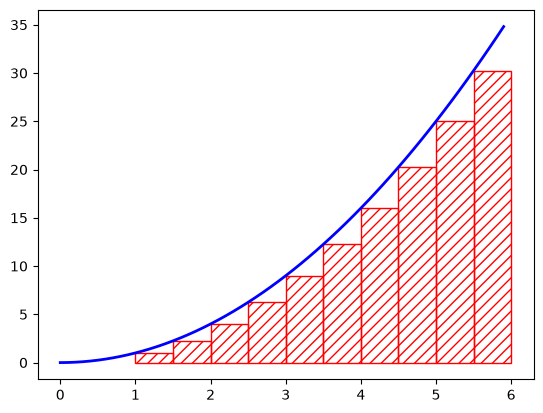

In [64]:
n = 10
deltax = (6-1)/n

xvalues = np.arange(1,6,deltax)
print(xvalues)
ax=plt.axes()

for x in xvalues:
    rect=patches.Rectangle((x,0), deltax, x**2, fill=False, color='red', hatch='///')
    ax.add_patch(rect)

x = np.arange(0,6,0.1)
ax.plot(x, x**2, color='blue', linewidth=2)

plt.show()

